<a href="https://colab.research.google.com/github/muhsinanizar18-droid/case_study/blob/main/Supervised_Learning_Case_Study_Muhsina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
train_df = pd.read_csv('/content/drive/MyDrive/DSA Activities /Supervised Learning Case Study/Training_data .csv')


In [ ]:
train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [ ]:
train_df.shape

(5634, 21)

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [ ]:
train_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [ ]:
train_df.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [ ]:
train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'],errors='coerce')

In [ ]:
train_df.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [ ]:
train_df['TotalCharges'] = train_df['TotalCharges'].fillna(train_df['TotalCharges'].median())

In [ ]:
train_df.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [ ]:
train_df['MonthlyCharges'] = train_df['MonthlyCharges'].fillna(train_df['MonthlyCharges'].median())

In [ ]:
train_df.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [ ]:
train_df['gender'] = train_df['gender'].fillna(train_df['gender'].mode()[0])

In [ ]:
train_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [ ]:
train_df['OnlineSecurity'] = train_df['OnlineSecurity'].fillna(train_df['OnlineSecurity'].mode()[0])

In [ ]:
train_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
train_df.duplicated().sum()

np.int64(0)

In [ ]:
X = train_df.drop('Churn',axis=1)
y = train_df['Churn']

In [ ]:
X = X.drop('customerID',axis=1)

In [ ]:
X['CustomerLifeTimeValue'] = (X['tenure']*X['MonthlyCharges'])

In [ ]:
categorical_columns = X.select_dtypes(include='object').columns
categorical_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [ ]:
X = pd.get_dummies(X,columns=categorical_columns,drop_first=True)

In [ ]:
le = LabelEncoder()
y = le.fit_transform(y)

le.classes_

array(['No', 'Yes'], dtype=object)

In [ ]:
X_train,X_val,y_train,y_val = train_test_split(X_scaled,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
log_model = LogisticRegression()
log_model.fit(X_train,y_train)
y_pred = log_model.predict(X_val)

In [ ]:
print(confusion_matrix(y_val,y_pred))
print(accuracy_score(y_val,y_pred))
print(classification_report(y_val,y_pred))

[[731  95]
 [127 174]]
0.80301685891748
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       826
           1       0.65      0.58      0.61       301

    accuracy                           0.80      1127
   macro avg       0.75      0.73      0.74      1127
weighted avg       0.80      0.80      0.80      1127



In [ ]:
pd.Series(y_val).value_counts()

,count
0,826
1,301


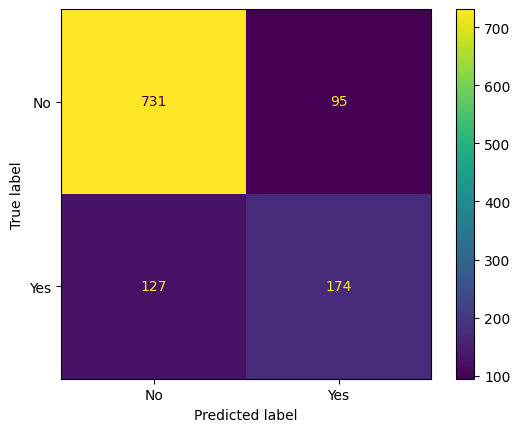

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_val,y_pred,display_labels=le.classes_)
plt.show()

Decision Tree Classifier

In [ ]:
dec_tree = DecisionTreeClassifier()
dec_tree.fit(X_train,y_train)
y_pred_dt = dec_tree.predict(X_val)

print(accuracy_score(y_val,y_pred_dt))
print(confusion_matrix(y_val,y_pred_dt))

0.7249334516415262
[[672 154]
 [156 145]]


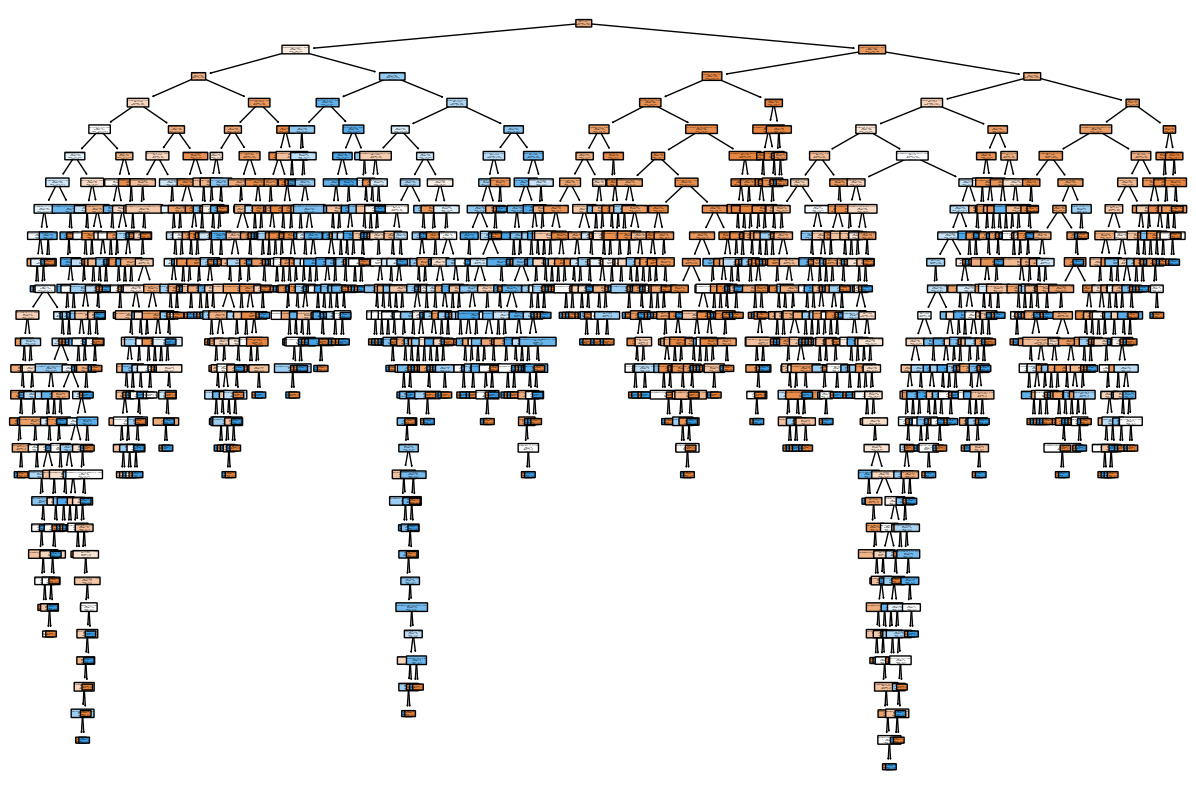

In [ ]:
from sklearn.tree import plot_tree

feature_names = X.columns.tolist()
class_names = le.classes_.tolist()

plt.figure(figsize=(15,10))
plot_tree(dec_tree,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True);
plt.show()

In [ ]:
dec_tree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [ ]:
dec_tree = DecisionTreeClassifier(random_state=30,
                                   min_samples_split=10,
                                   min_samples_leaf=5,
                                   max_depth=2)
dec_tree.fit(X_train,y_train)
y_pred_dt = dec_tree.predict(X_val)

print(accuracy_score(y_val,y_pred_dt))
print(confusion_matrix(y_val,y_pred_dt))

0.7914818101153505
[[767  59]
 [176 125]]


In [ ]:
dec_tree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 2,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 5,
 'min_samples_split': 10,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 30,
 'splitter': 'best'}

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf = rf_model.predict(X_val)

print(accuracy_score(y_val,y_pred_rf))
print(confusion_matrix(y_val,y_pred_rf))

0.8012422360248447
[[746  80]
 [144 157]]


In [ ]:
rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [ ]:
rf_model = RandomForestClassifier(random_state=42,
                                   n_estimators=200,
                                   n_jobs=-1,
                                   class_weight='balanced',
                                  max_depth=10,
                                  min_samples_split=5)
rf_model.fit(X_train,y_train)
y_pred_rf = rf_model.predict(X_val)

print(accuracy_score(y_val,y_pred_rf))
print(confusion_matrix(y_val,y_pred_rf))

0.7852706299911268
[[659 167]
 [ 75 226]]


In [ ]:
result = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree','Random Forest'],
    'Accuracy':[accuracy_score(y_val,y_pred),accuracy_score(y_val,y_pred_dt),accuracy_score(y_val,y_pred_rf)]
})

result

,Model,Accuracy
0,Logistic Regression,0.803017
1,Decision Tree,0.791482
2,Random Forest,0.785271


In [ ]:
best_model = rf_model

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [10,20,30,100,200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=param_grid,cv=5,scoring="accuracy",n_jobs=-1)
grid_search.fit(X_train,y_train)

best_rf_model = grid_search.best_estimator_
print(best_rf_model)

RandomForestClassifier(max_depth=10, min_samples_split=5, random_state=42)


In [ ]:
y_pred_best_rf = best_rf_model.predict(X_val)
print(accuracy_score(y_val,y_pred_best_rf))

0.8118899733806566


In [ ]:
test_df = pd.read_csv('/content/drive/MyDrive/DSA Activities /Supervised Learning Case Study/Testing_data .csv')

In [ ]:
test_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [ ]:
test_df.shape

(1409, 21)

In [ ]:
test_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,1409.000000,1409.000000,1409.000000
mean,0.171753,31.428673,63.898013
std,0.377300,24.322161,30.282693
min,0.000000,0.000000,18.700000
25%,0.000000,8.000000,30.100000
50%,0.000000,27.000000,69.900000
75%,0.000000,54.000000,89.500000
max,1.000000,72.000000,118.600000


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [ ]:
test_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
X_test = test_df.drop('Churn',axis=1)
y_test = test_df['Churn']

In [ ]:
X_test = X_test.drop("customerID",axis=1)

In [ ]:
X_test["CustomerLifeTimeValue"] = (X_test["tenure"]* X_test["MonthlyCharges"])

In [ ]:
X_test = pd.get_dummies(X_test,columns=X_test.select_dtypes(include="object").columns,drop_first=True)

In [ ]:
X_test = X_test.reindex(columns=X.columns,fill_value=0)

In [ ]:
y_test = le.transform(y_test)

In [ ]:
X_test_scaled = scaler.transform(X_test)

In [ ]:
test_pred = best_rf_model.predict(X_test_scaled)

In [ ]:
print("Test Accuracy:",accuracy_score(y_test,test_pred))

Test Accuracy: 0.8005677785663591


In [ ]:
print(classification_report(y_test,test_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1044
           1       0.63      0.55      0.59       365

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [ ]:
cm = confusion_matrix(y_test,test_pred)
print(cm)

[[929 115]
 [166 199]]


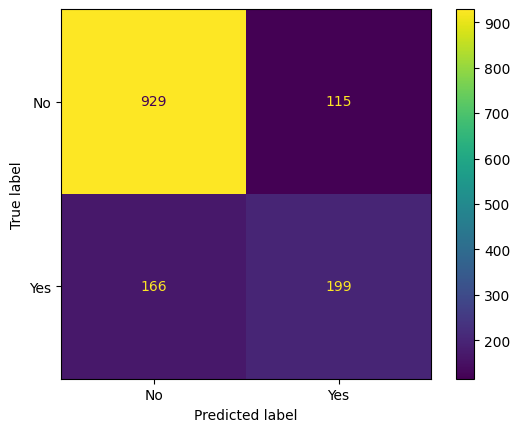

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,test_pred,display_labels=le.classes_)
plt.show()

The results show that hyperparameter tuning improved the Random Forest model. The tuned model achieved 81.19% validation accuracy, making it the preferred Random Forest configuration for the final model.